# Densest subgraph

## Executive summary

### 1. Greedy peeling algorithm

We implemented the greedy peeling algorithm closely following the lecture notes. In each step, the algorithm computes the current density, removes a vertex of minimum degree, and continues with the remaining graph. The implementation uses the linked-list based bucket structure from the lecture notes, so vertices can be moved between degree buckets efficiently during the peeling process.

To keep the running time linear, we first store all degrees in an array and then keep an array of doubly linked lists, where list k contains all vertices of current degree k. We also store a pointer from every vertex to its position in the correct list, and we maintain a variable k* for the smallest non-empty degree bucket. This means that when an edge is removed, we only move the neighbor once from one bucket to the next smaller one, and each edge is touched only when it is deleted.

One small challenge is that the algorithm destroys the graph while it runs, but at the end we still need the best subgraph and not only its score. Instead of copying the whole edge set whenever we see a better solution, we store the number of already removed vertices at the best point. After the peeling process is finished, we reconstruct the best vertex set from this removal order. This keeps the implementation simple and avoids losing the linear runtime.

### 2. Results for the density objective

For the OpenFlights dataset, the density objective gives the following five clusters:

- Cluster 1, |S| = 180: a large international hub cluster with many airports from the US and Western Europe.
- Cluster 2, |S| = 53: an almost purely Chinese domestic network.
- Cluster 3, |S| = 29: a South Asia and Middle East cluster with many airports from India, Pakistan and Saudi Arabia.
- Cluster 4, |S| = 57: a more unusual mixed cluster with many Russian and Brazilian airports.
- Cluster 5, |S| = 18: a compact Australia and New Zealand cluster.

This shows that the density objective can recover both a very large global hub structure and smaller regional flight networks.

For the Facebook dataset, the density objective also returns several clearly interpretable clusters:

- Cluster 1, |S| = 324: mainly US military and government pages, but also some TV show pages. Examples are 101st Airborne Division, 1st Infantry Division and 24: Legacy.
- Cluster 2, |S| = 89: EU institutions and official EU pages. Examples are Commission européenne en France, Council of Europe and EU Budget.
- Cluster 3, |S| = 662: a very large mixed politics and government cluster with diplomatic pages and politicians from several countries. Examples are Africa Regional Media Hub, American Center New Delhi and Anthony Albanese MP.
- Cluster 4, |S| = 55: French ministries and prefectures. Examples are Ministère de la Justice, Police Nationale and Préfecture de Police.
- Cluster 5, |S| = 311: another broad politician-heavy cluster with many Australian political and diplomatic pages. Examples are Alan Tudge MP, Andrew Scheer and Australia in India.

So on Facebook, the density objective sometimes gives very clear thematic communities, but in other rounds it prefers larger and looser groups.

### 3. Results for the Tsourakakis objective

When we changed the objective function, the results became more specific. For OpenFlights, the five clusters are:

- Cluster 1, |S| = 93: a smaller Western European core.
- Cluster 2, |S| = 45: a mostly US domestic network.
- Cluster 3, |S| = 55: again a Chinese domestic cluster.
- Cluster 4, |S| = 29: again a South Asia and Middle East cluster.
- Cluster 5, |S| = 22: a mostly Brazilian domestic group.

The modified objective therefore keeps some of the same regional structures, but it removes many airports from the broader international clusters and keeps only tighter subsets.

On Facebook, the difference was even stronger. The five Tsourakakis clusters are:

- Cluster 1, |S| = 60: only TV shows. Examples are Brooklyn Nine-Nine, Family Guy and Empire.
- Cluster 2, |S| = 129: US Army and related military institutions. Examples are 101st Airborne Division, 3rd Infantry Division and Aberdeen Proving Ground.
- Cluster 3, |S| = 89: again a cluster of EU institutions. Examples are Council of the European Union, EU Budget and EU Environment.
- Cluster 4, |S| = 38: South Korean government pages. Examples are Ministry of Science and ICT, Ministry of Health and Welfare, Republic of Korea, and 대한민국 법무부.
- Cluster 5, |S| = 41: mainly Australian Labor politicians. Examples are Anthony Albanese MP, Bill Shorten MP and Julia Gillard.

So in our results, the density objective tends to return larger and broader groups, while the Tsourakakis objective tends to return smaller and more clique-like communities. This difference is visible on both datasets, but especially on Facebook.

<div style="page-break-after: always; break-after: page; height: 1px;"></div>

## Basic Graph Class

We already provide the basic implementation of a graph class.

Iterating over nodes can be done by using ```for u in G.nodesToEdges``` and iterating over the edges incident upon node ```u``` can be done using ```for v in G.nodesToEdges[u]```. To check whether an edge $(u,v)$ exists use ```G.edgeExists(u,v)```.

Graphs can be read from files using the ```readFromFile```-procedure. Using the optional argument ```verticesToIgnore``` which expects a ```set()``` as input, you may exclude some nodes from the graph, i.e., if ```verticesToIgnore``` is some set $S$ then it will load the graph $G=(V\setminus S,E[V\setminus S])$.  Note that you might have to delete header-rows from some data files to make the procedure work.

In [42]:
class Graph:
    def __init__(self):
        self.numNodes = 0
        self.numEdges = 0

        self.edges = set()
        self.nodesToEdges = {}

    def addEdge(self,u,v):
        if u == v or v in self.nodesToEdges and u in self.nodesToEdges[v]:
            return
            
        self.numEdges += 1
        self.addNeighbor(u,v)
        self.addNeighbor(v,u)
        self.edges.add((u,v)) # we only add one pair (u,v) and not (v,u)

    def removeEdge(self,u,v):
        self.numEdges -= 1
        self.nodesToEdges[u].remove(v)
        self.nodesToEdges[v].remove(u)

        if (u,v) in self.edges:
            self.edges.remove((u,v))
        else: # (v,u) in self.edges
            self.edges.remove((v,u))

    def addNeighbor(self,u,v):
        if u not in self.nodesToEdges:
            self.numNodes += 1
            self.nodesToEdges[u] = set()

        self.nodesToEdges[u].add(v)

    def edgeExists(self, u, v):
        return ((u,v) in self.edges or (v,u) in self.edges)
        
    def degree(self, u):
        return len(self.nodesToEdges[u])

    def readFromFile(self, filePath, separator=',', verticesToIgnore=set()):
        with open(filePath, 'r') as f:
            for line in f:
                split = line.split(separator)
                u = int(split[0])
                v = int(split[1])

                if u in verticesToIgnore or v in verticesToIgnore:
                    continue
                    
                self.addEdge(u, v)

        print(f'Finished reading graph with {self.numNodes} nodes and {self.numEdges} edges.')

## Basic Linked List Data Structure

First, implement your own linked list data structure ```LinkedList``` in which each element is from the class ```LinkedListElement```.

In [43]:
class LinkedListElement:
    def __init__(self,id,prevElement=None,nextElement=None):
        self.id = id
        self.prevElement = prevElement
        self.nextElement = nextElement

class LinkedList:
    def __init__(self):
        self.head = None
        self.tail = None
        self.size = 0

    def appendElement(self, element: LinkedListElement):
        if self.head is None:
            self.head = element
            self.tail = element
        else:
            element.prevElement = self.tail
            self.tail.nextElement = element
            self.tail = element
        self.size += 1

    def removeElement(self, element: LinkedListElement):
        if element == self.head:
            self.head = element.nextElement

        if element == self.tail:
            self.tail = element.prevElement

        if element.prevElement:
            element.prevElement.nextElement = element.nextElement
        if element.nextElement:
            element.nextElement.prevElement = element.prevElement

        element.nextElement = None
        element.prevElement = None
        self.size -= 1
        
    def pop(self):
        if not self.tail:
            return None
        node_to_remove = self.tail
        self.removeElement(node_to_remove)
        return node_to_remove

## Implementation of the Greedy Peeling Algorithm

Next, implement the greedy peeling algorithm. The function should be callable using ```densestSubgraphGreedyPeeling(G)``` where ```G``` is a graph using the graph class from above. Besides G, the function may accept more optional arguments.

In [44]:
def objectiveValue(num_edges, num_nodes, objective='density'):
    match objective:
        case 'density':
            return num_edges / num_nodes
        case 'tsourakakis':
            return num_edges - (num_nodes * (num_nodes - 1)) / 6
        case 'clique_likeness':
            if num_nodes < 2:
                return 0
            return num_edges / (num_nodes * (num_nodes - 1) / 2)
        case _:
            raise ValueError(f'Unknown objective: {objective}')

def densestSubgraphGreedyPeeling(G, objective='density'):
    max_id = max(G.nodesToEdges) # needed to allow non-continuous labeling
    d = [0] * (max_id + 1)
    # im assuming here that the vertices are named 0 - n <-- now also fine with a few "holes"
    for e in G.edges:
        d[e[0]] += 1
        d[e[1]] += 1

    L = list()
    for _ in range(0, G.numNodes):
        L.append(LinkedList())

    k_star = float('inf')
    pointers_to_vertices = [None] * (max_id + 1)  # needed to allow non-continuous labeling
    #for v, degree in enumerate(d):
    for v in G.nodesToEdges:   # works with a non-continuous degree list
        degree = d[v]
        element = LinkedListElement(v)
        L[degree].appendElement(element)
        pointers_to_vertices[v] = element

        if degree < k_star:
            k_star = degree

    #best_S = G.edges.copy() # O(m)
    best_num_edges = G.numEdges
    best_score = objectiveValue(G.numEdges, G.numNodes, objective)
    removed_vertices = []
    best_removed_count = 0
    num_nodes = G.numNodes
    while num_nodes != 1:
        v_star = L[k_star].pop()
        removed_vertices.append(v_star.id)
        neighbors = G.nodesToEdges[v_star.id].copy() # O(m)
        for u in neighbors:
            G.removeEdge(v_star.id, u)
            current = pointers_to_vertices[u]
            L[d[current.id]].removeElement(current) # remove from L[d[u]]
            d[current.id] -= 1
            L[d[current.id]].appendElement(current) # add to L[d[u]-1]

            if d[current.id] < k_star:
                k_star = d[current.id]
        num_nodes -= 1


        score = objectiveValue(G.numEdges, num_nodes, objective)
        if score > best_score:
            best_num_edges = G.numEdges
            best_score = score
            #best_S = G.edges.copy() # O(m) <- we are inside a O(n) loop, this would result in O(n*m)
            best_removed_count = len(removed_vertices)

        while k_star < len(L) and L[k_star].size <= 0:
            k_star = (k_star + 1) % G.numNodes

    best_S = set(removed_vertices[best_removed_count:]) # "get back" all vertices that were removed, after optimum was found
    best_S.add(L[k_star].head.id) # also add last vertex still in the list

    return best_S, best_num_edges, best_score

def runDisjointSubgraphExtraction(filePath, objective='density'):
    verticesToIgnore = set()
    results = []

    for round_idx in range(1, 6):
        working_graph = Graph()
        working_graph.readFromFile(filePath, ',', verticesToIgnore)
        vertex_set, num_edges, score = densestSubgraphGreedyPeeling(working_graph, objective)

        results.append({
            'round': round_idx,
            'vertex_set': set(vertex_set),
            'num_vertices': len(vertex_set),
            'num_edges': num_edges,
            'score': score,
        })
        verticesToIgnore.update(vertex_set)

    return results

#testGraph = Graph()
#testGraph.addEdge(0,1)
#testGraph.addEdge(1,2)
#testGraph.addEdge(1,3)
#testGraph.addEdge(1,25)
#testGraph.addEdge(2,3)
#testGraph.addEdge(2,25)
#testGraph.addEdge(3,25)
#densestSubgraphGreedyPeeling(testGraph)

## Experiments for Densest Subgraph

Now, the experiments for the two datasets follow.

### Experiments for the OpenFlights Dataset

In [45]:
openflights_disjoint_subgraphs = runDisjointSubgraphExtraction('data/openflights_edges_cleaned.csv')

for result in openflights_disjoint_subgraphs:
    print(f"Round {result['round']}:")
    print(f"|S| = {result['num_vertices']}, density = {result['score']}\n")


Finished reading graph with 3214 nodes and 18858 edges.
Finished reading graph with 2643 nodes and 7349 edges.
Finished reading graph with 2513 nodes and 5716 edges.
Finished reading graph with 2415 nodes and 4953 edges.
Finished reading graph with 2234 nodes and 4027 edges.
Round 1:
|S| = 180, density = 25.377777777777776

Round 2:
|S| = 53, density = 14.754716981132075

Round 3:
|S| = 29, density = 7.482758620689655

Round 4:
|S| = 57, density = 5.385964912280702

Round 5:
|S| = 18, density = 4.611111111111111



### AI-Assisted OpenFlights Visualizations

The following cell was written with AI assistance. It creates one overview world map for all five OpenFlights clusters and five additional cluster-specific maps that also display the intra-cluster flight edges. The figures are shown in the notebook and saved as PNG files in the `generated/` directory.

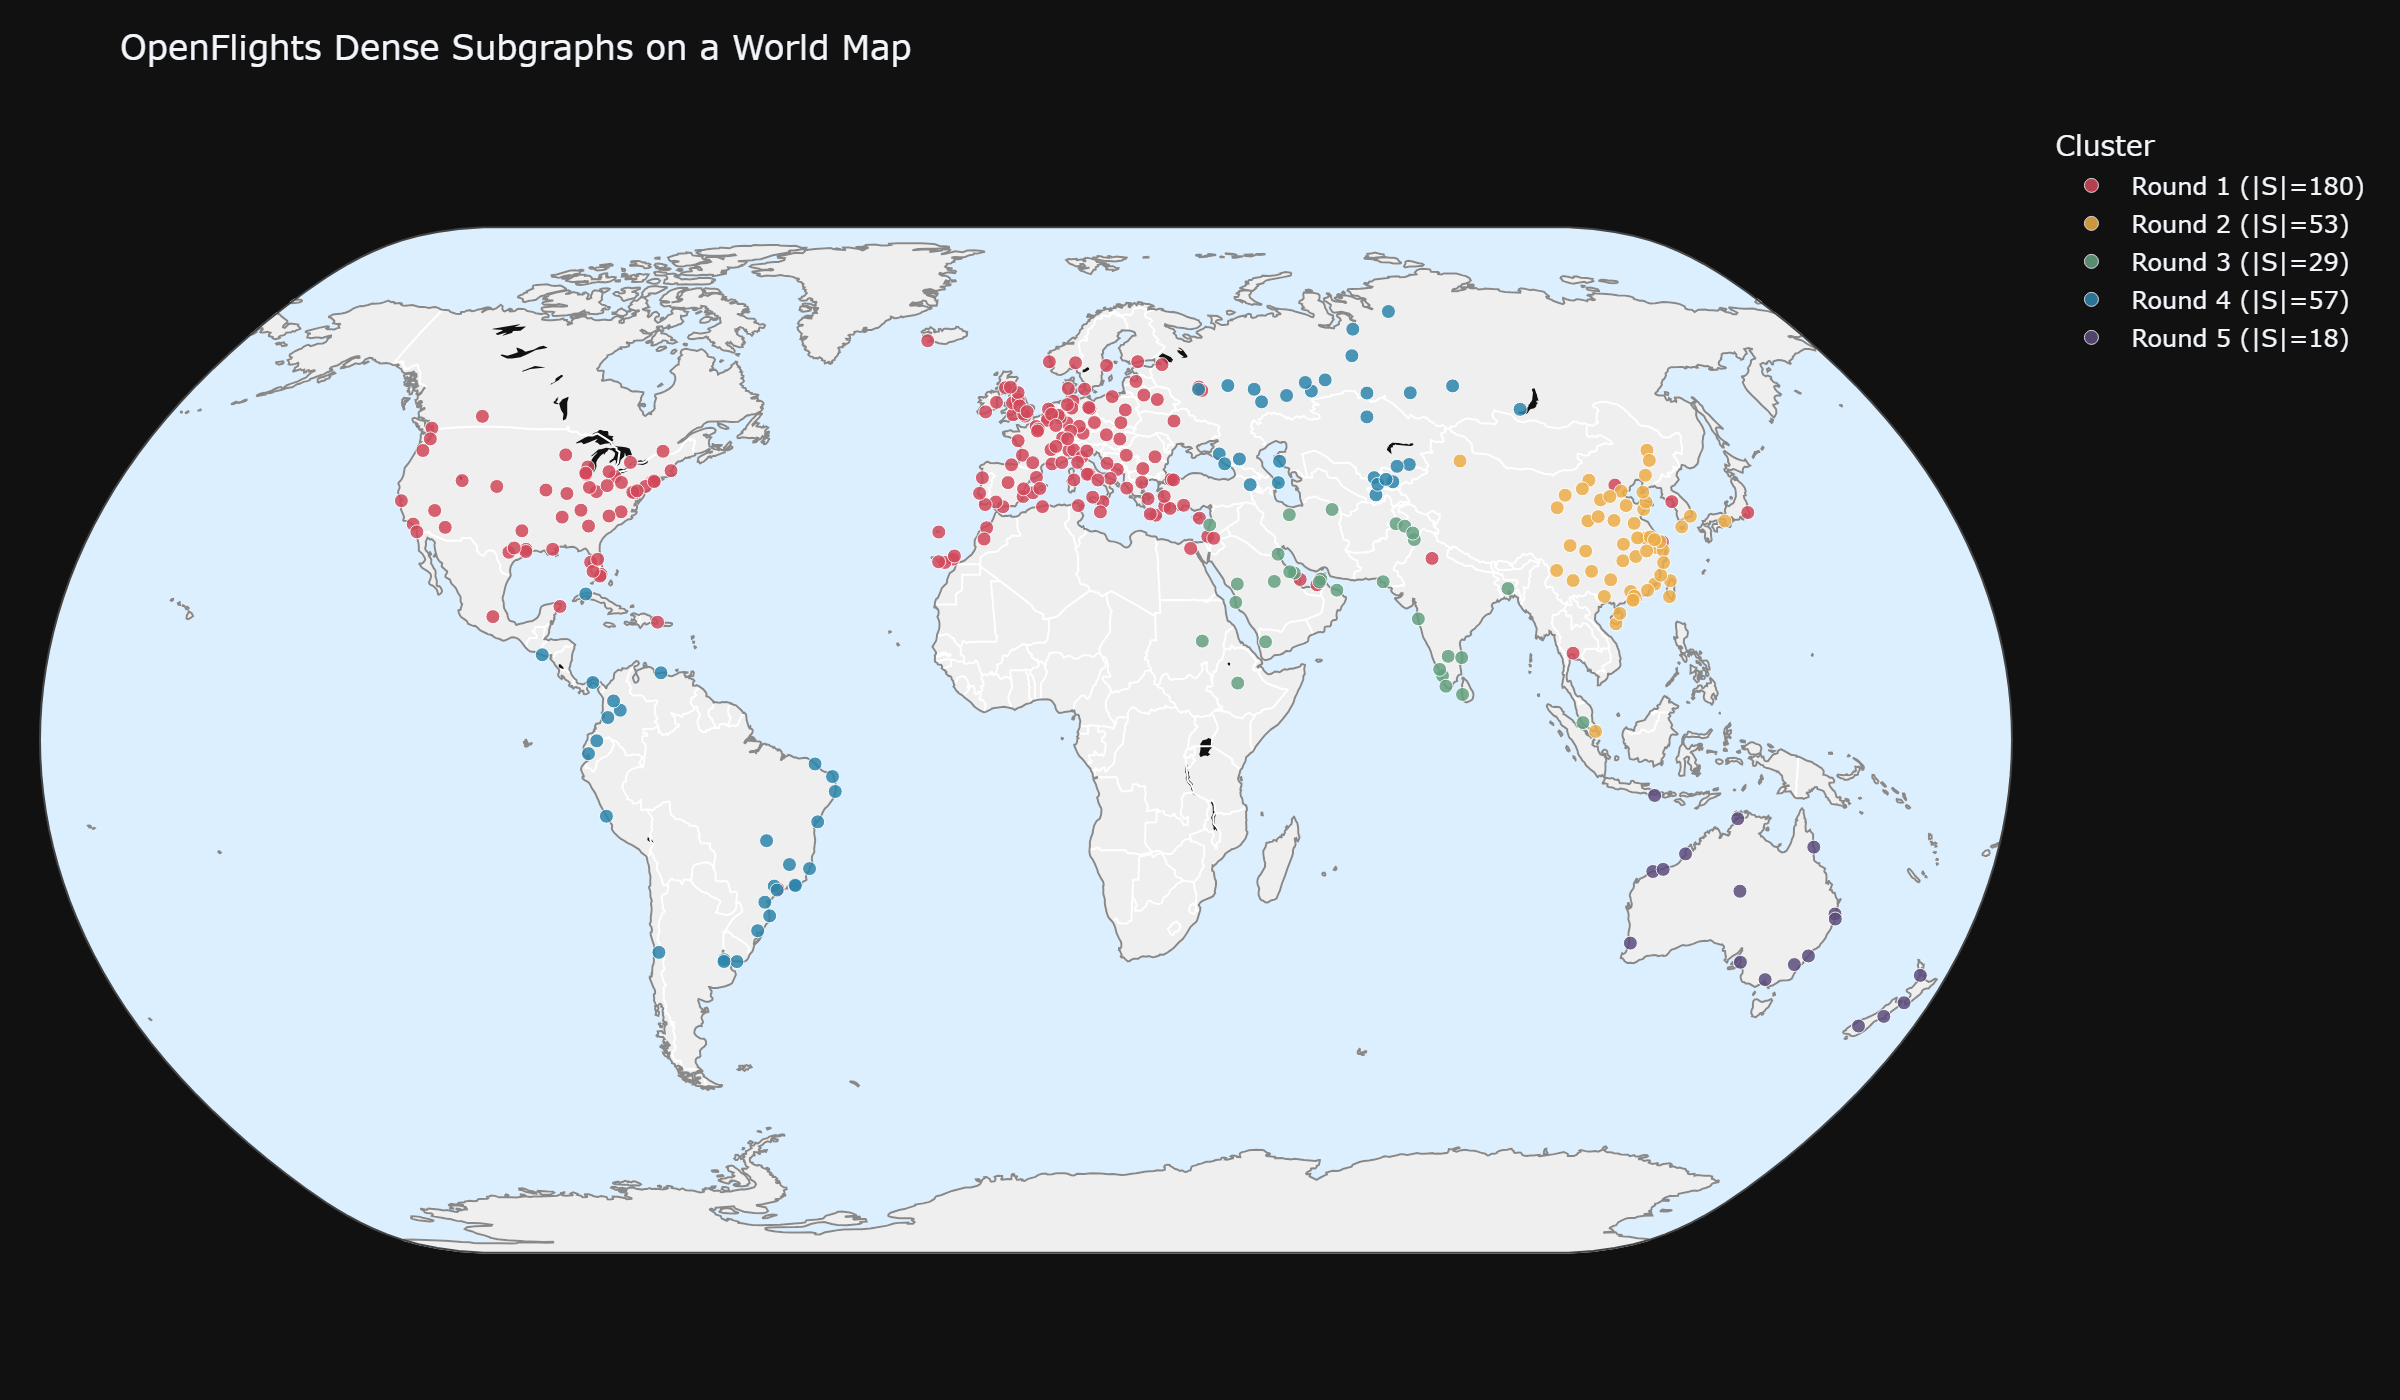

Saved overview map to generated\openflights_clusters_world_map.png


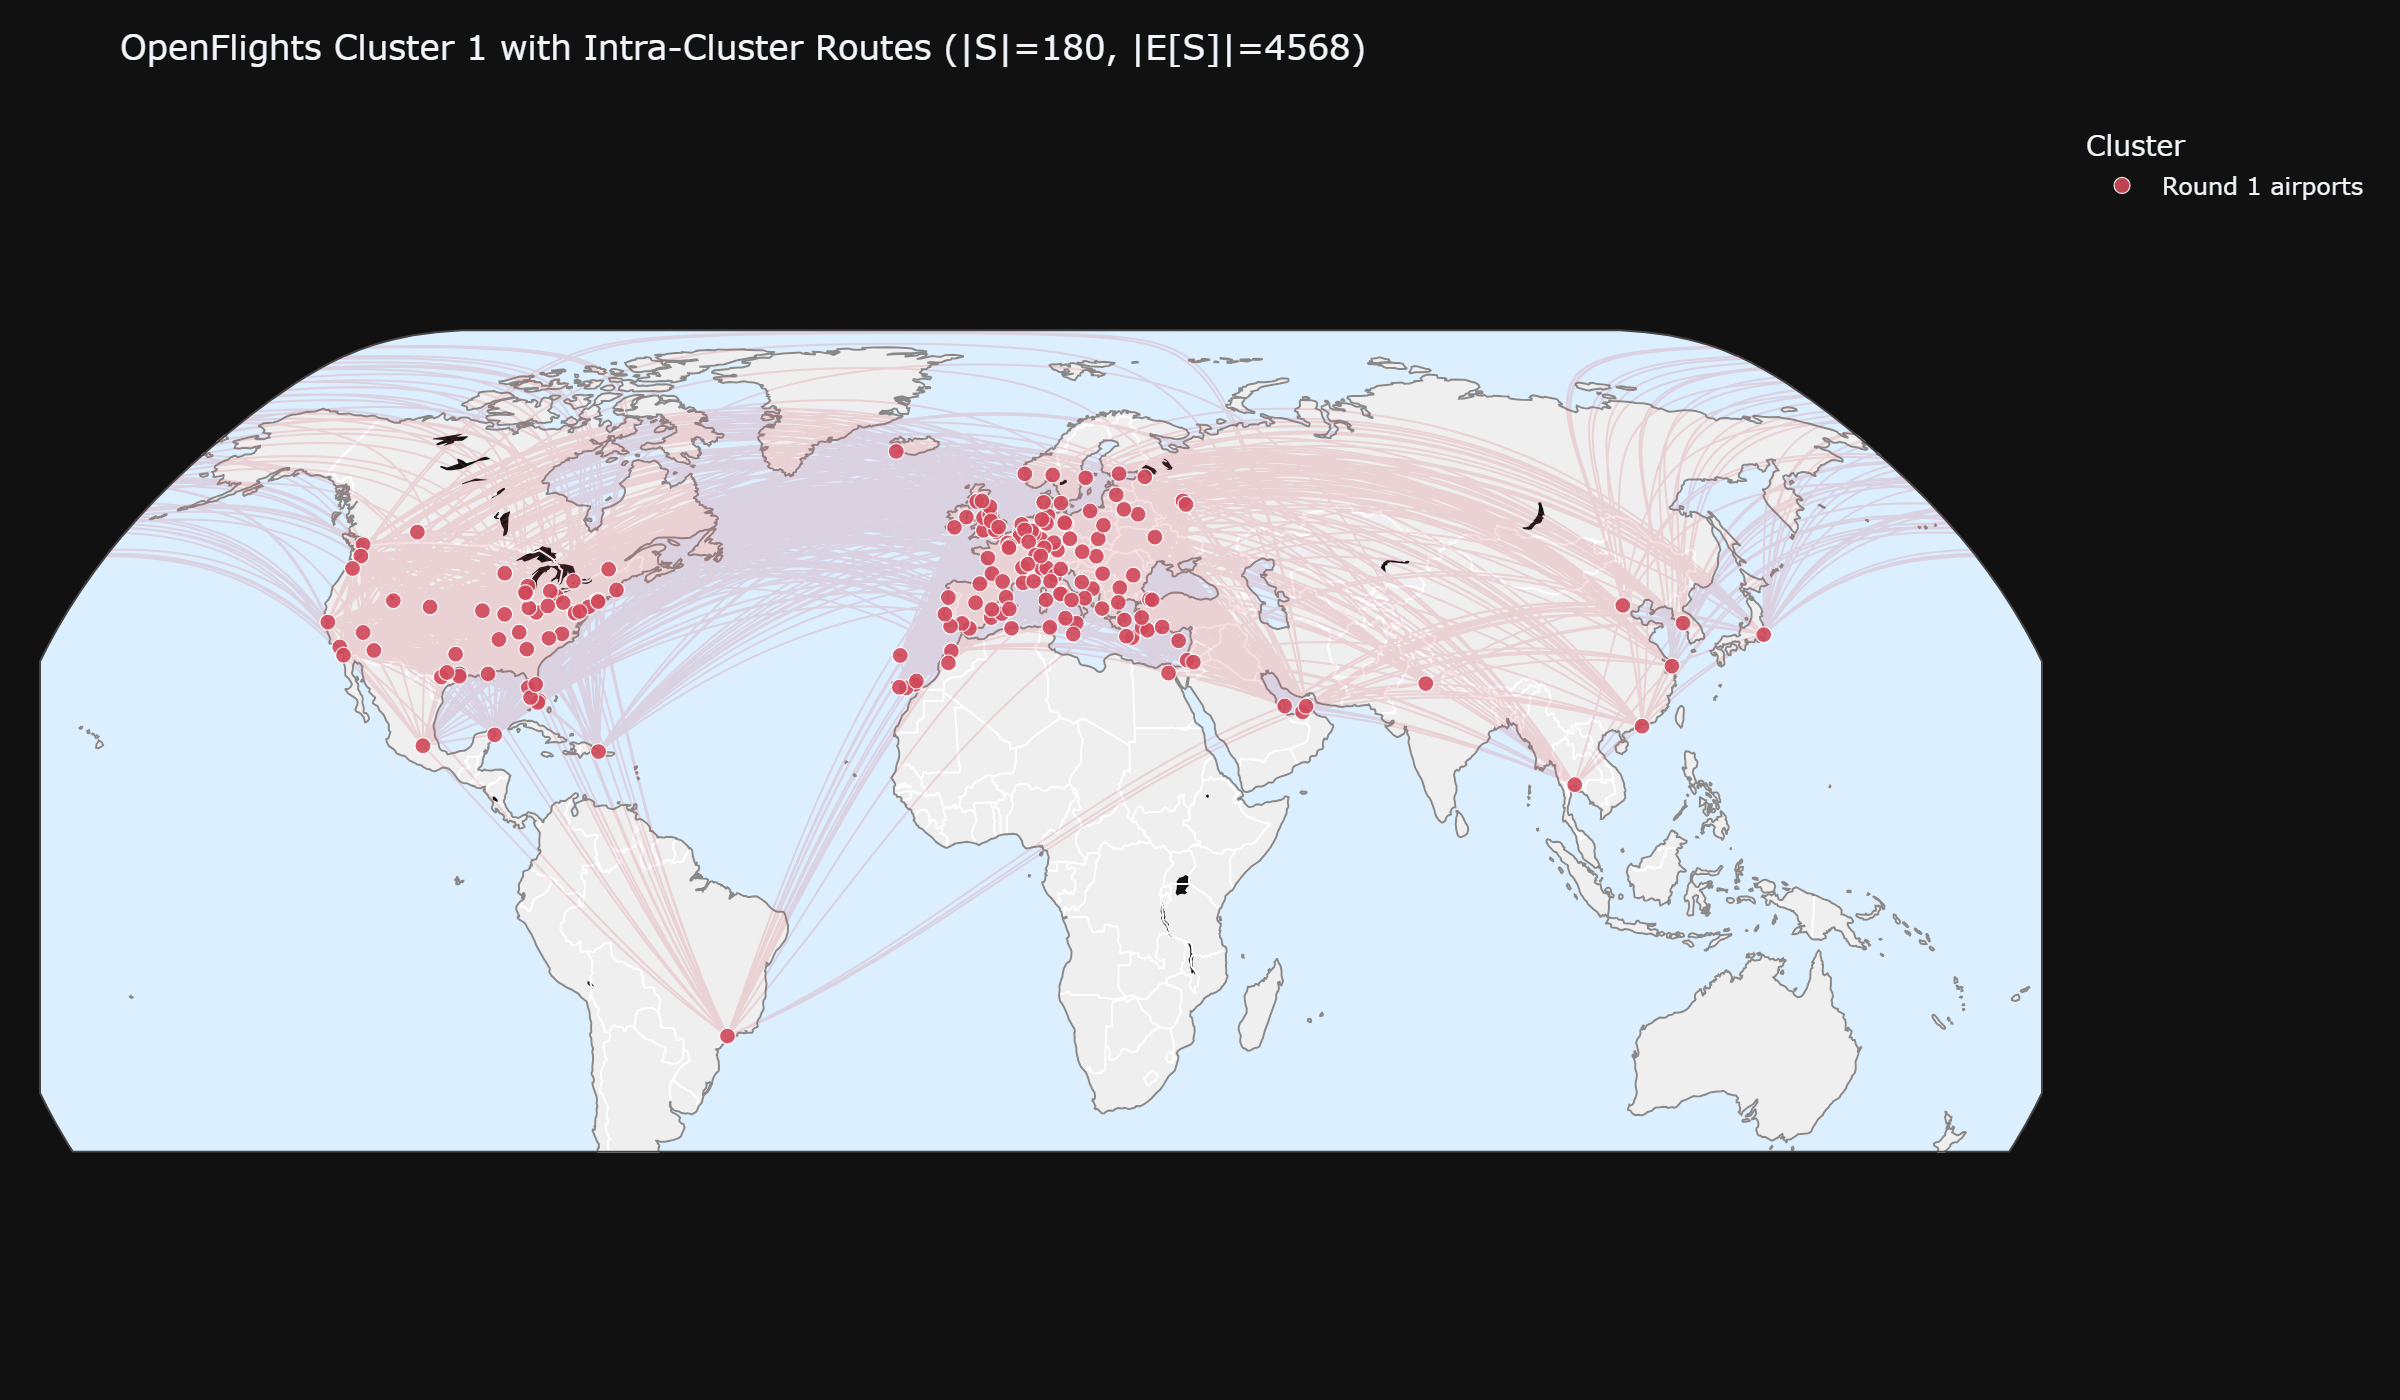

Saved cluster map to generated\openflights_cluster_1.png


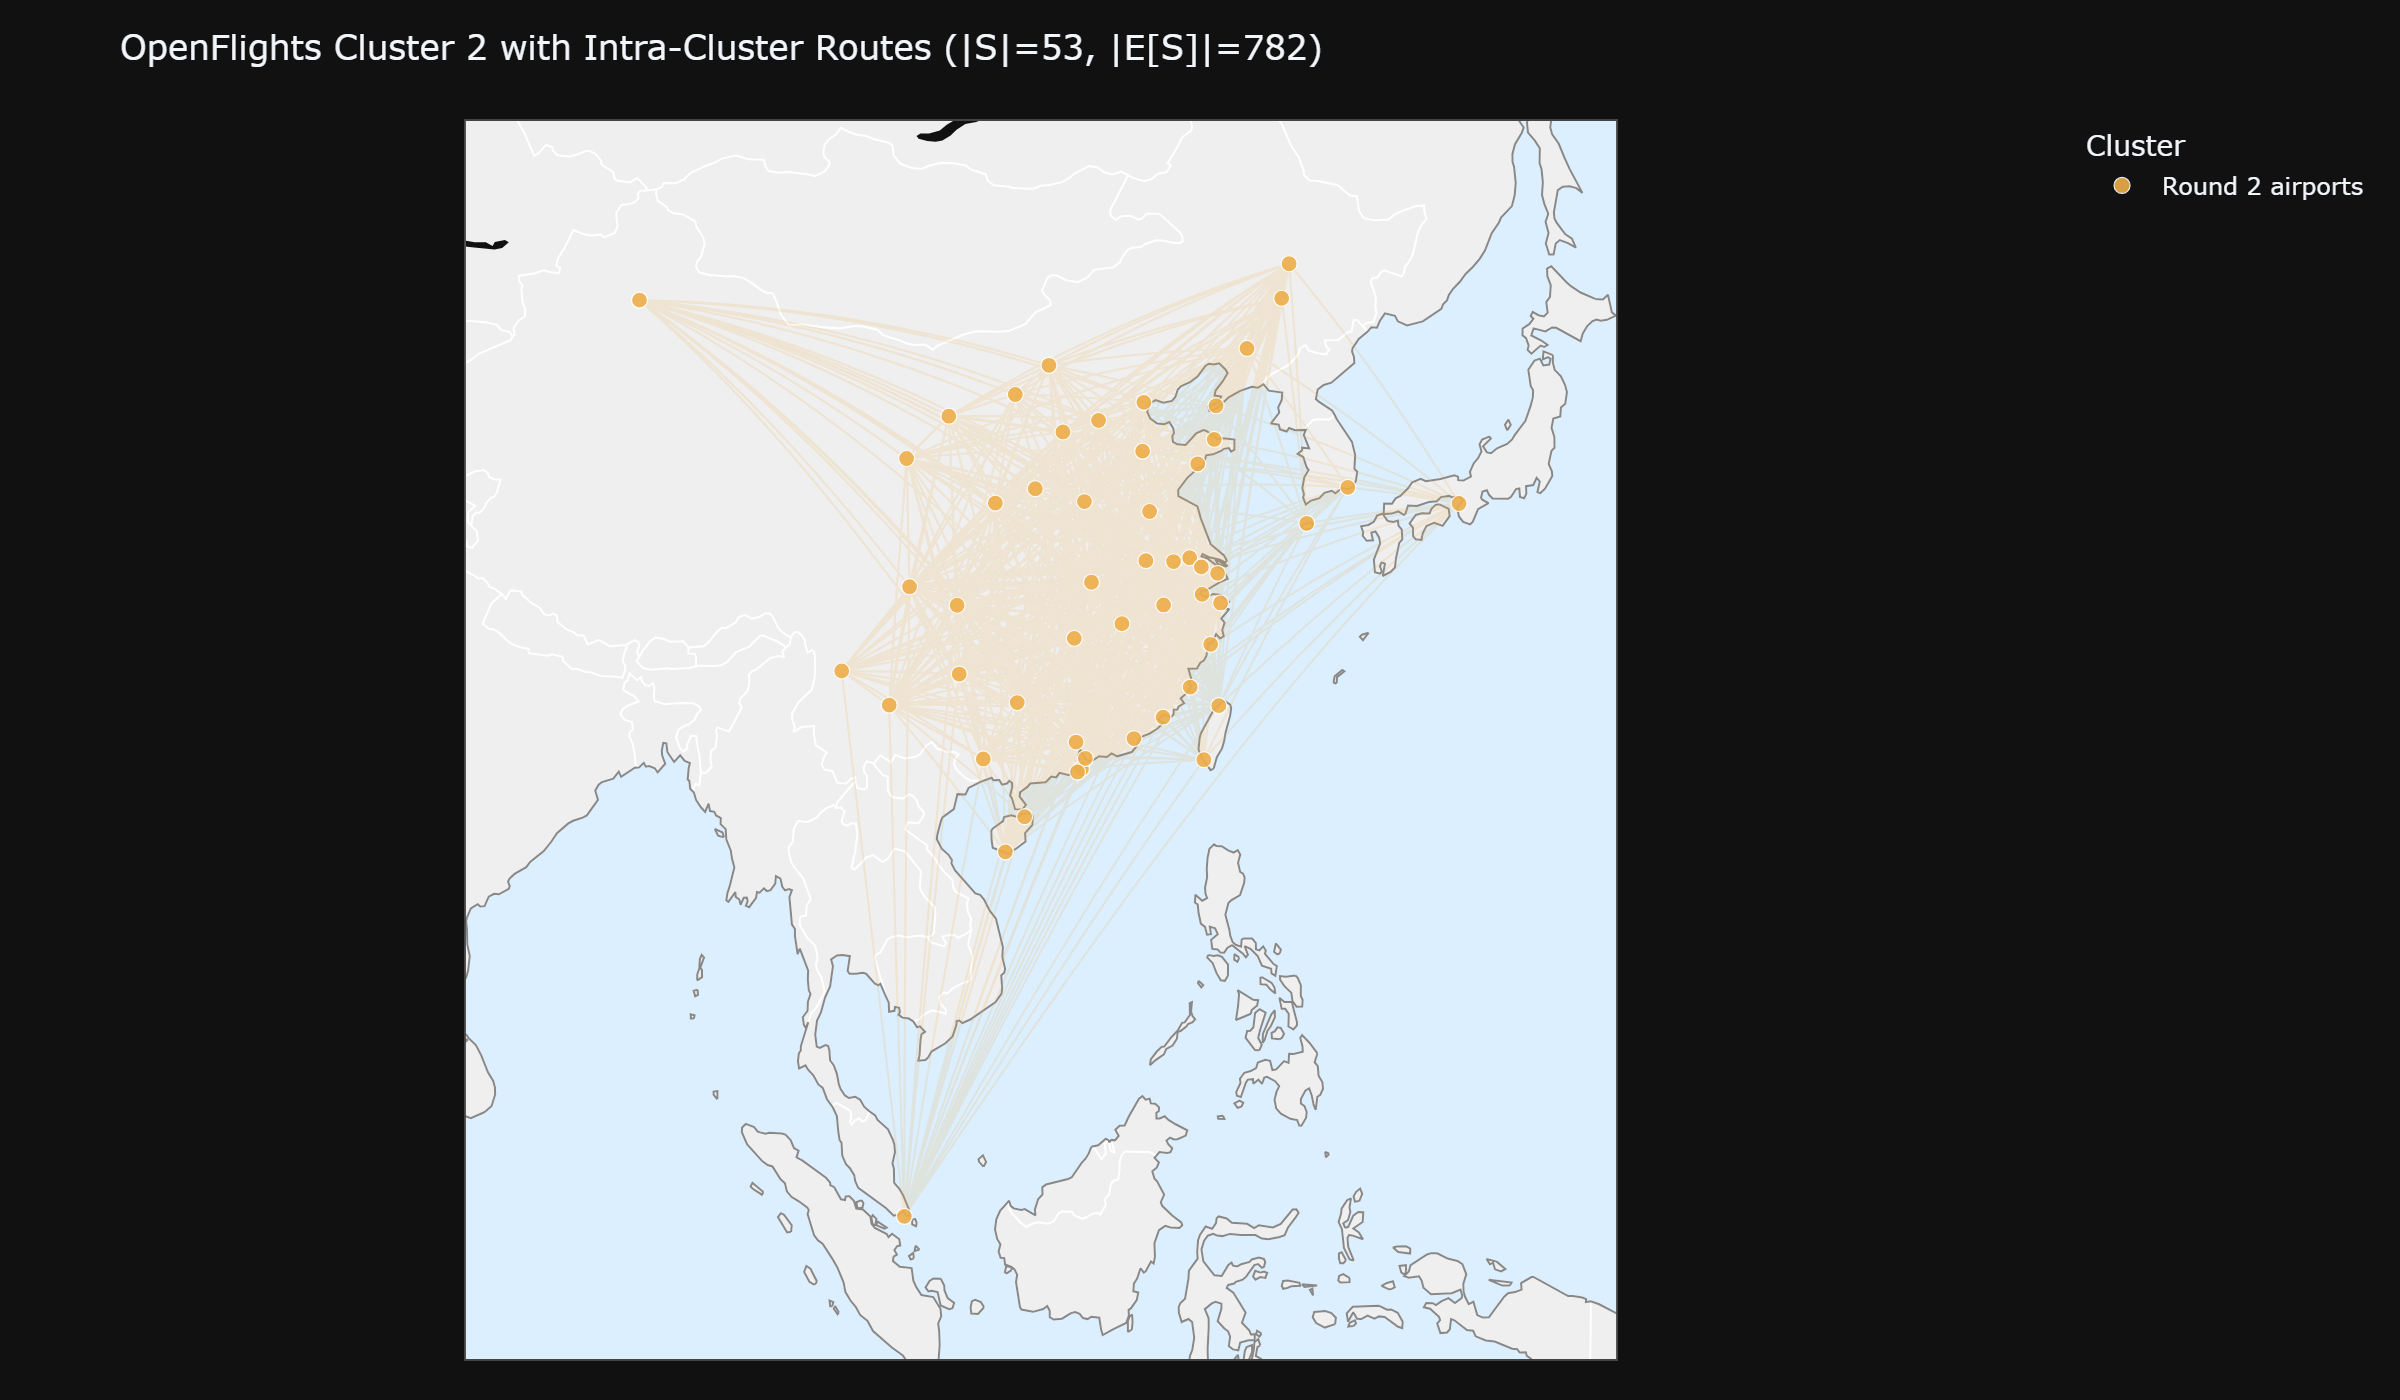

Saved cluster map to generated\openflights_cluster_2.png


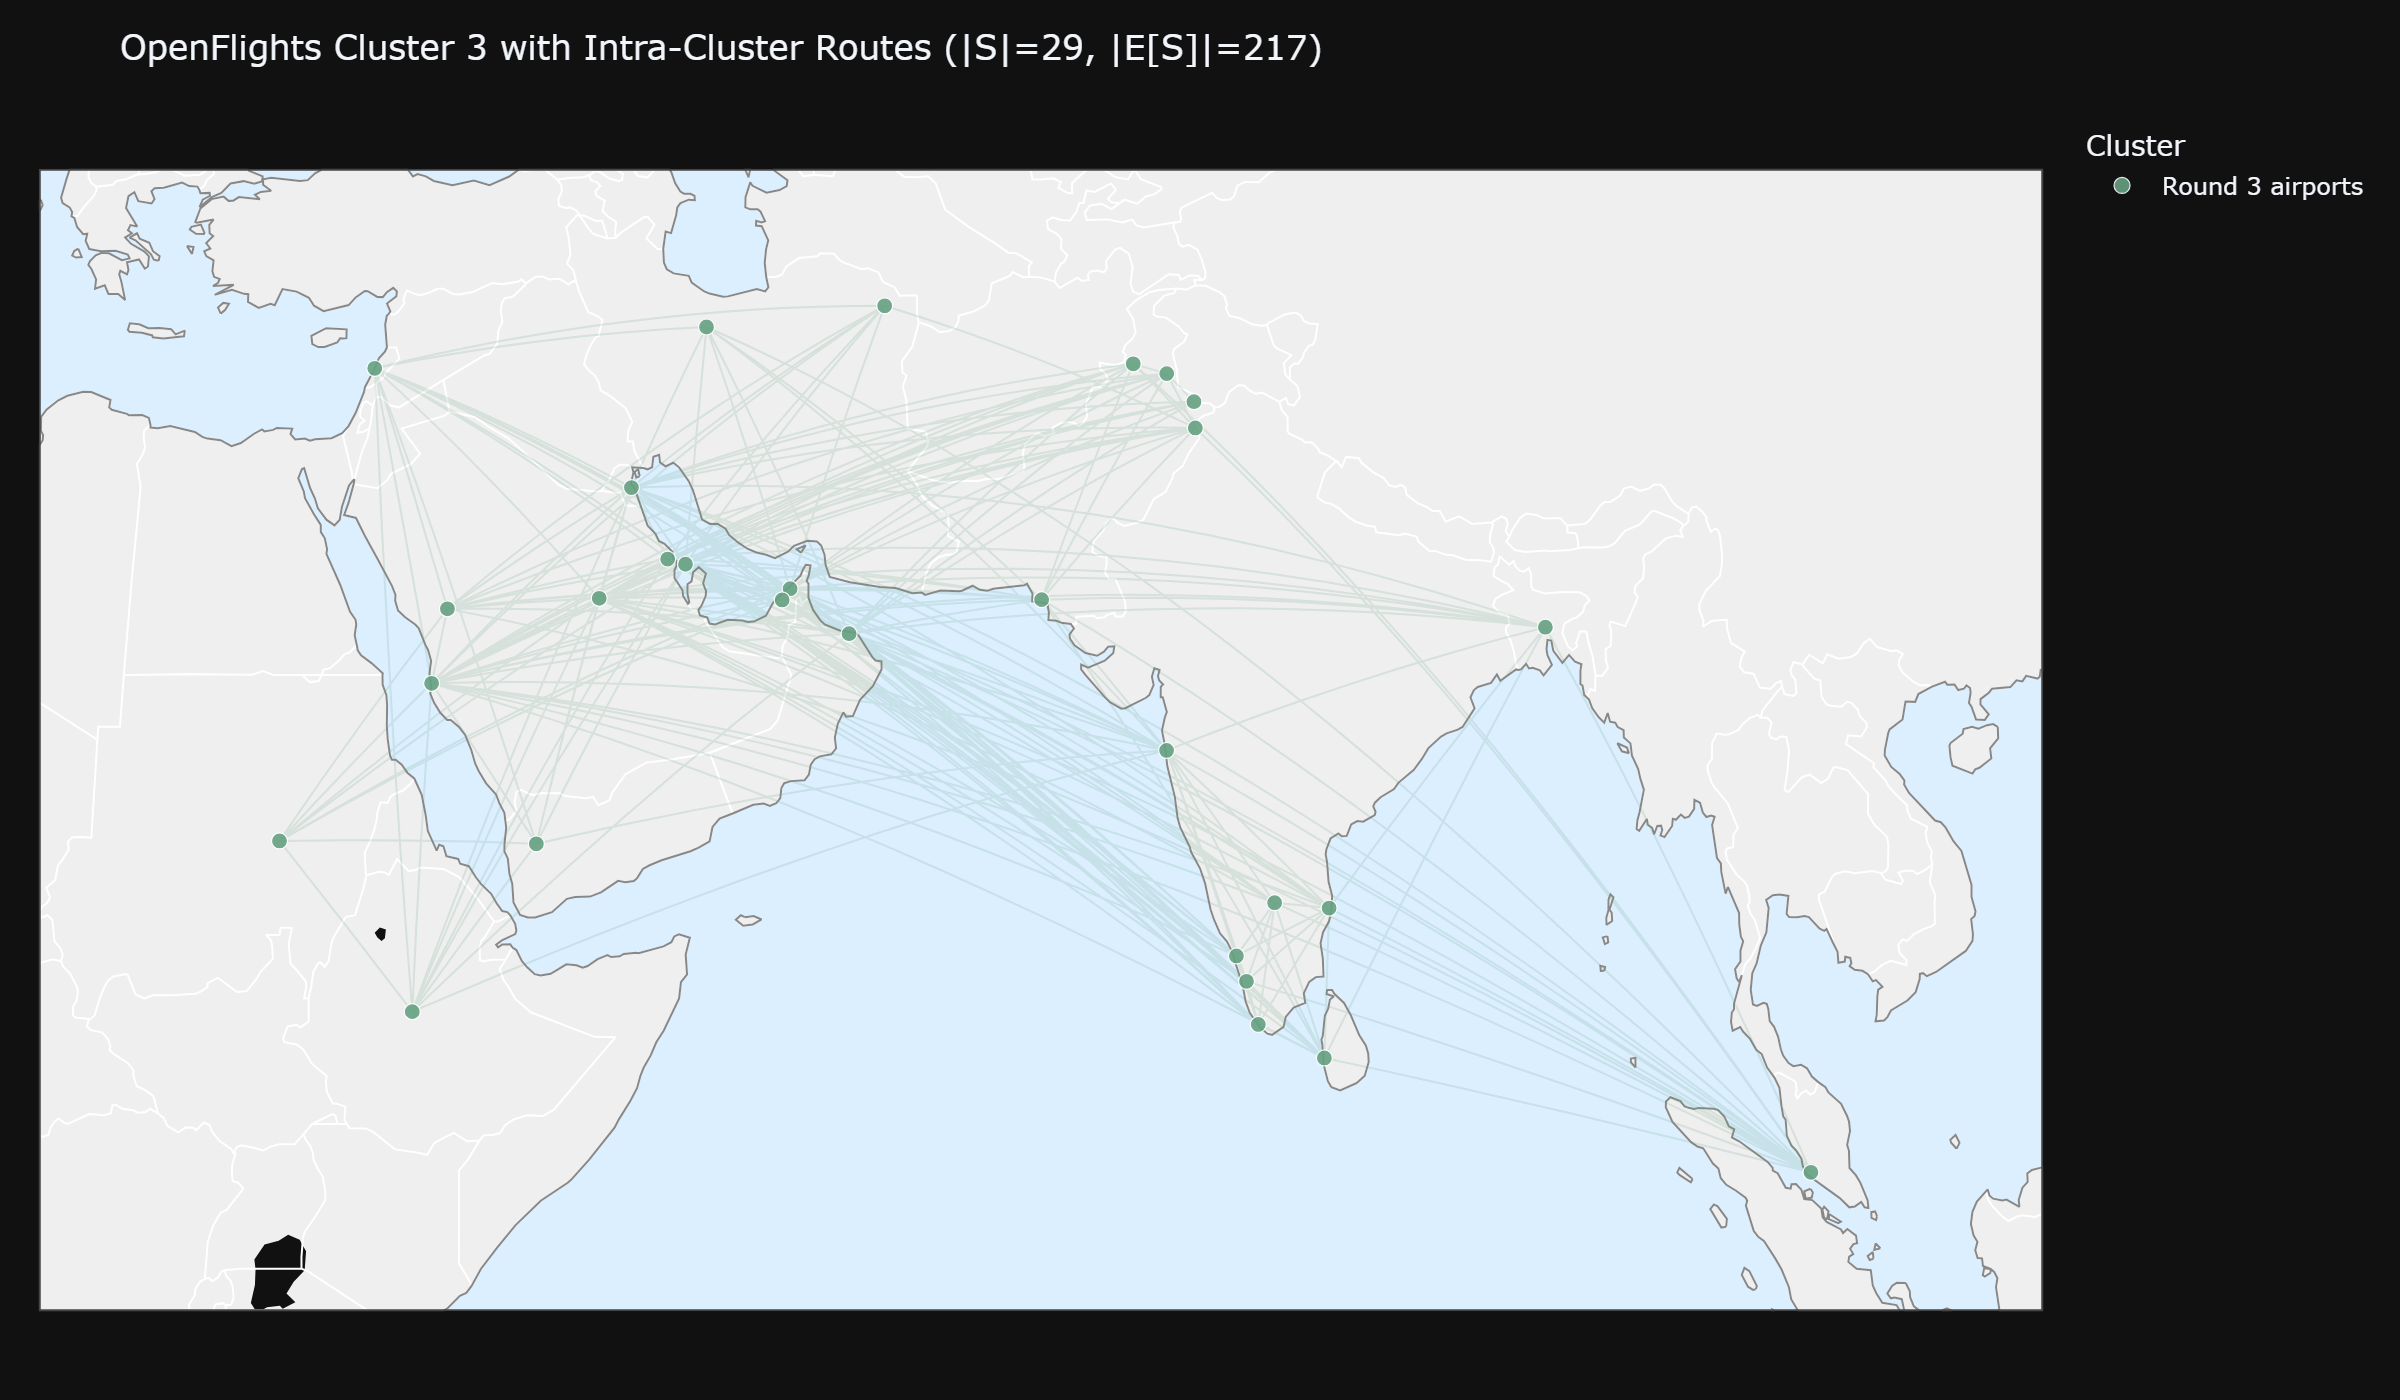

Saved cluster map to generated\openflights_cluster_3.png


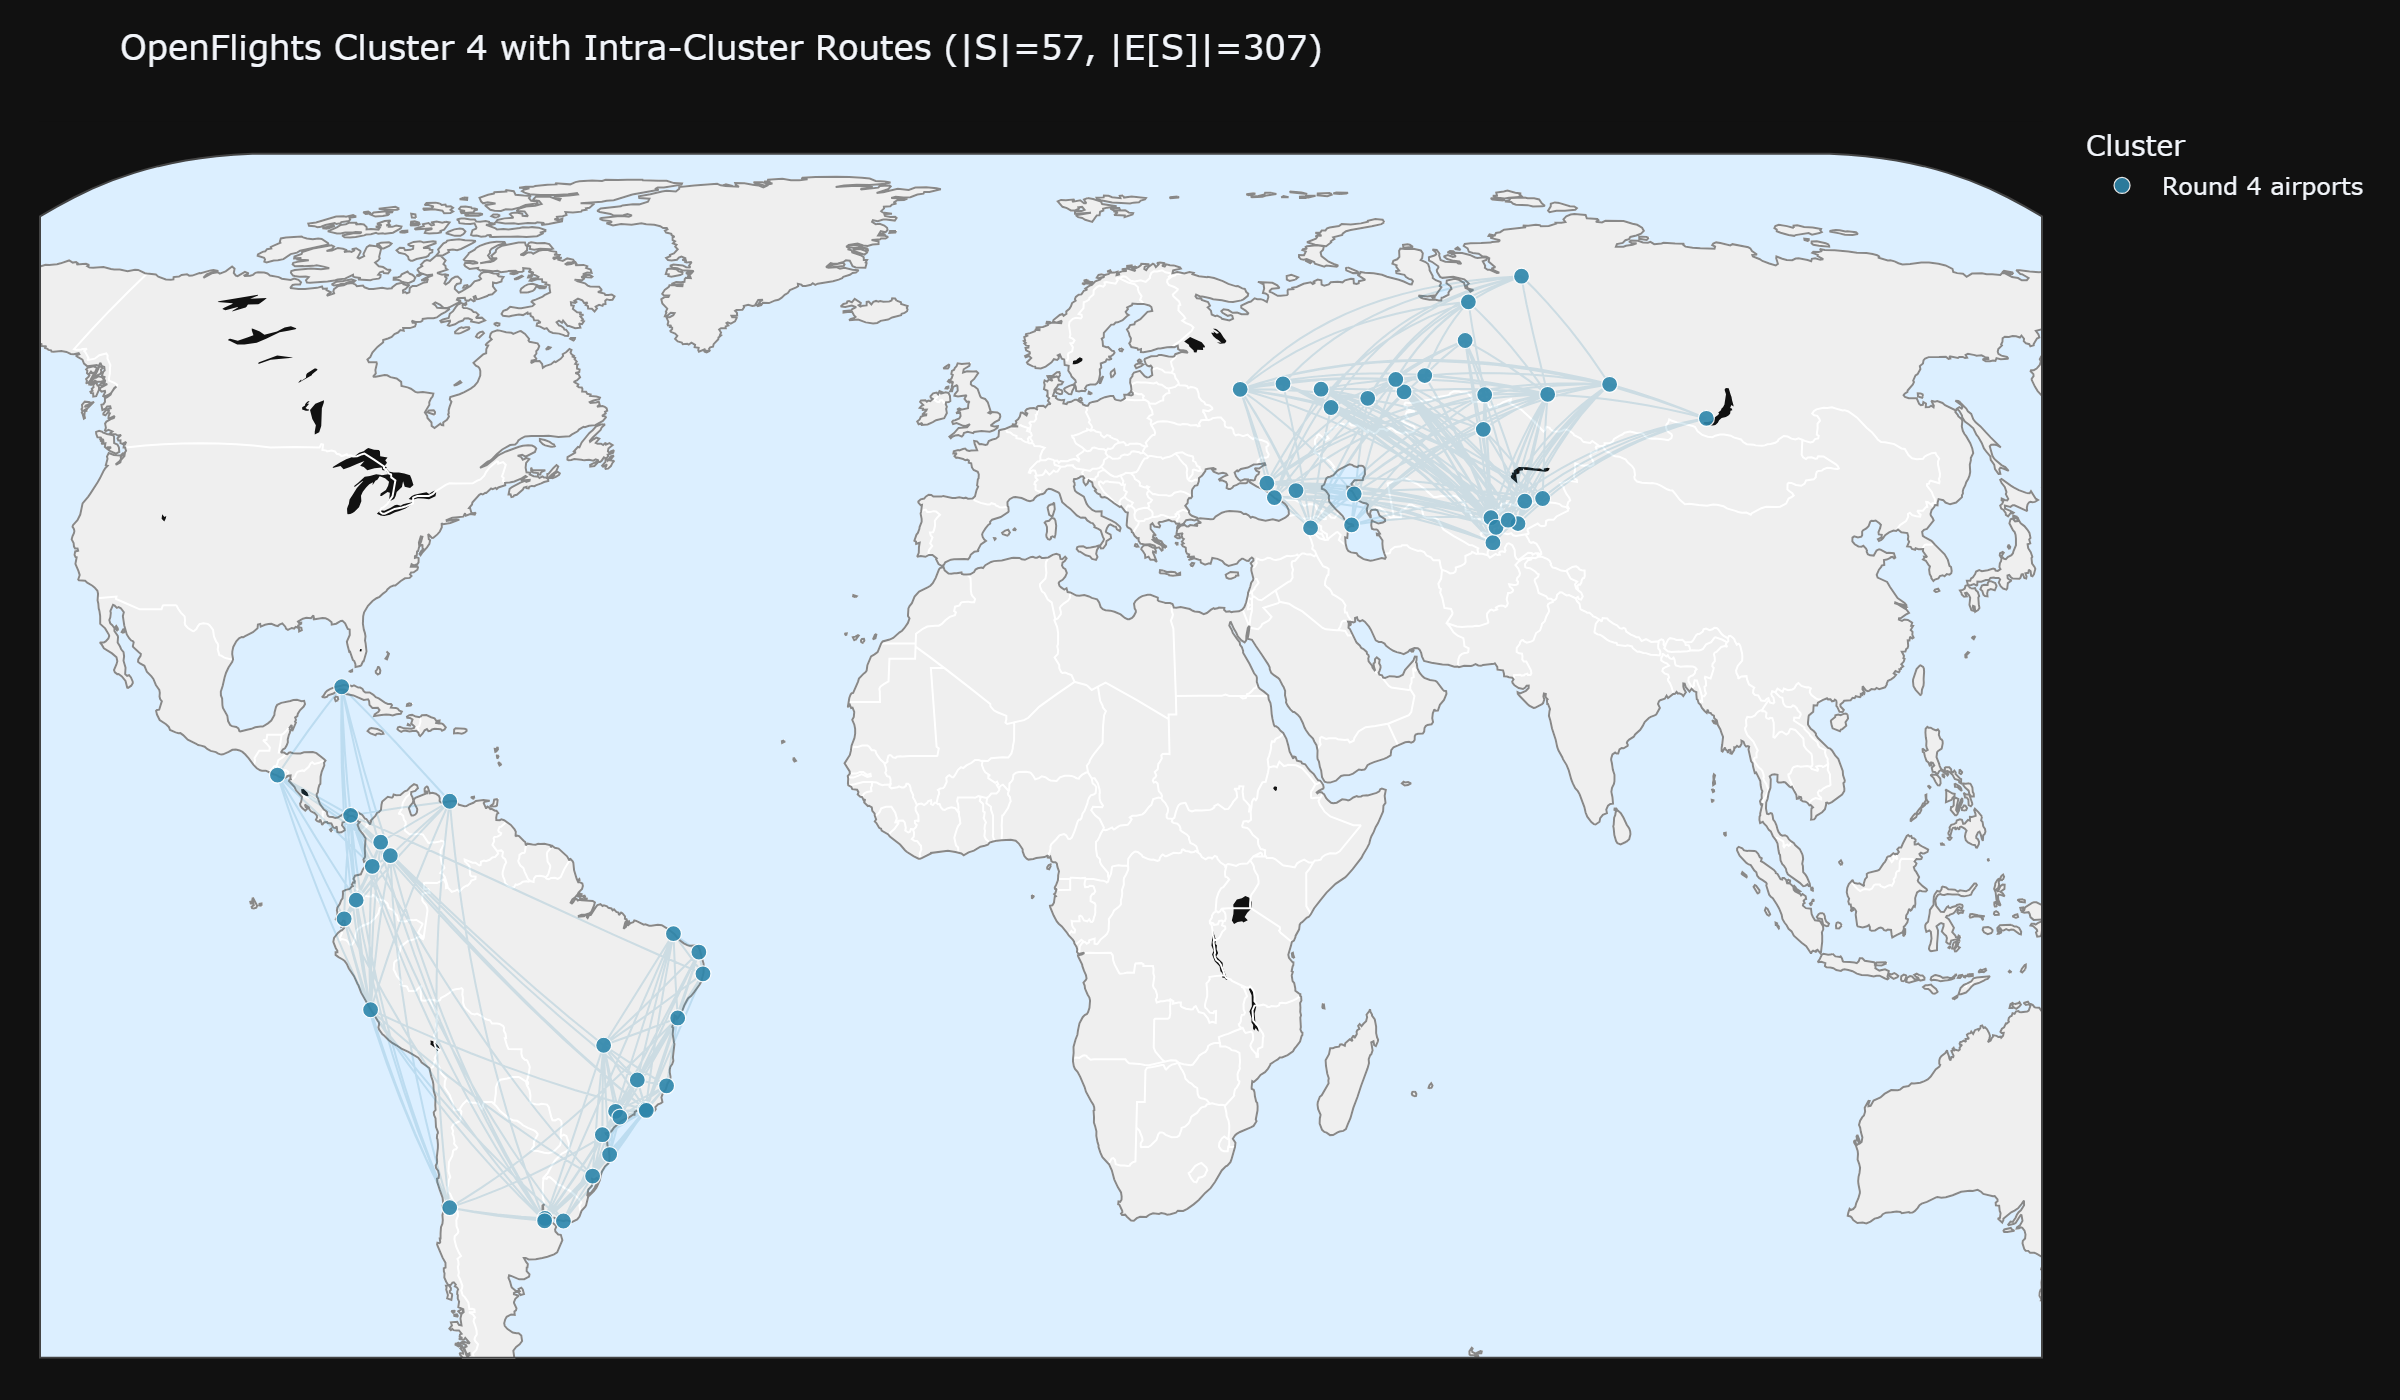

Saved cluster map to generated\openflights_cluster_4.png


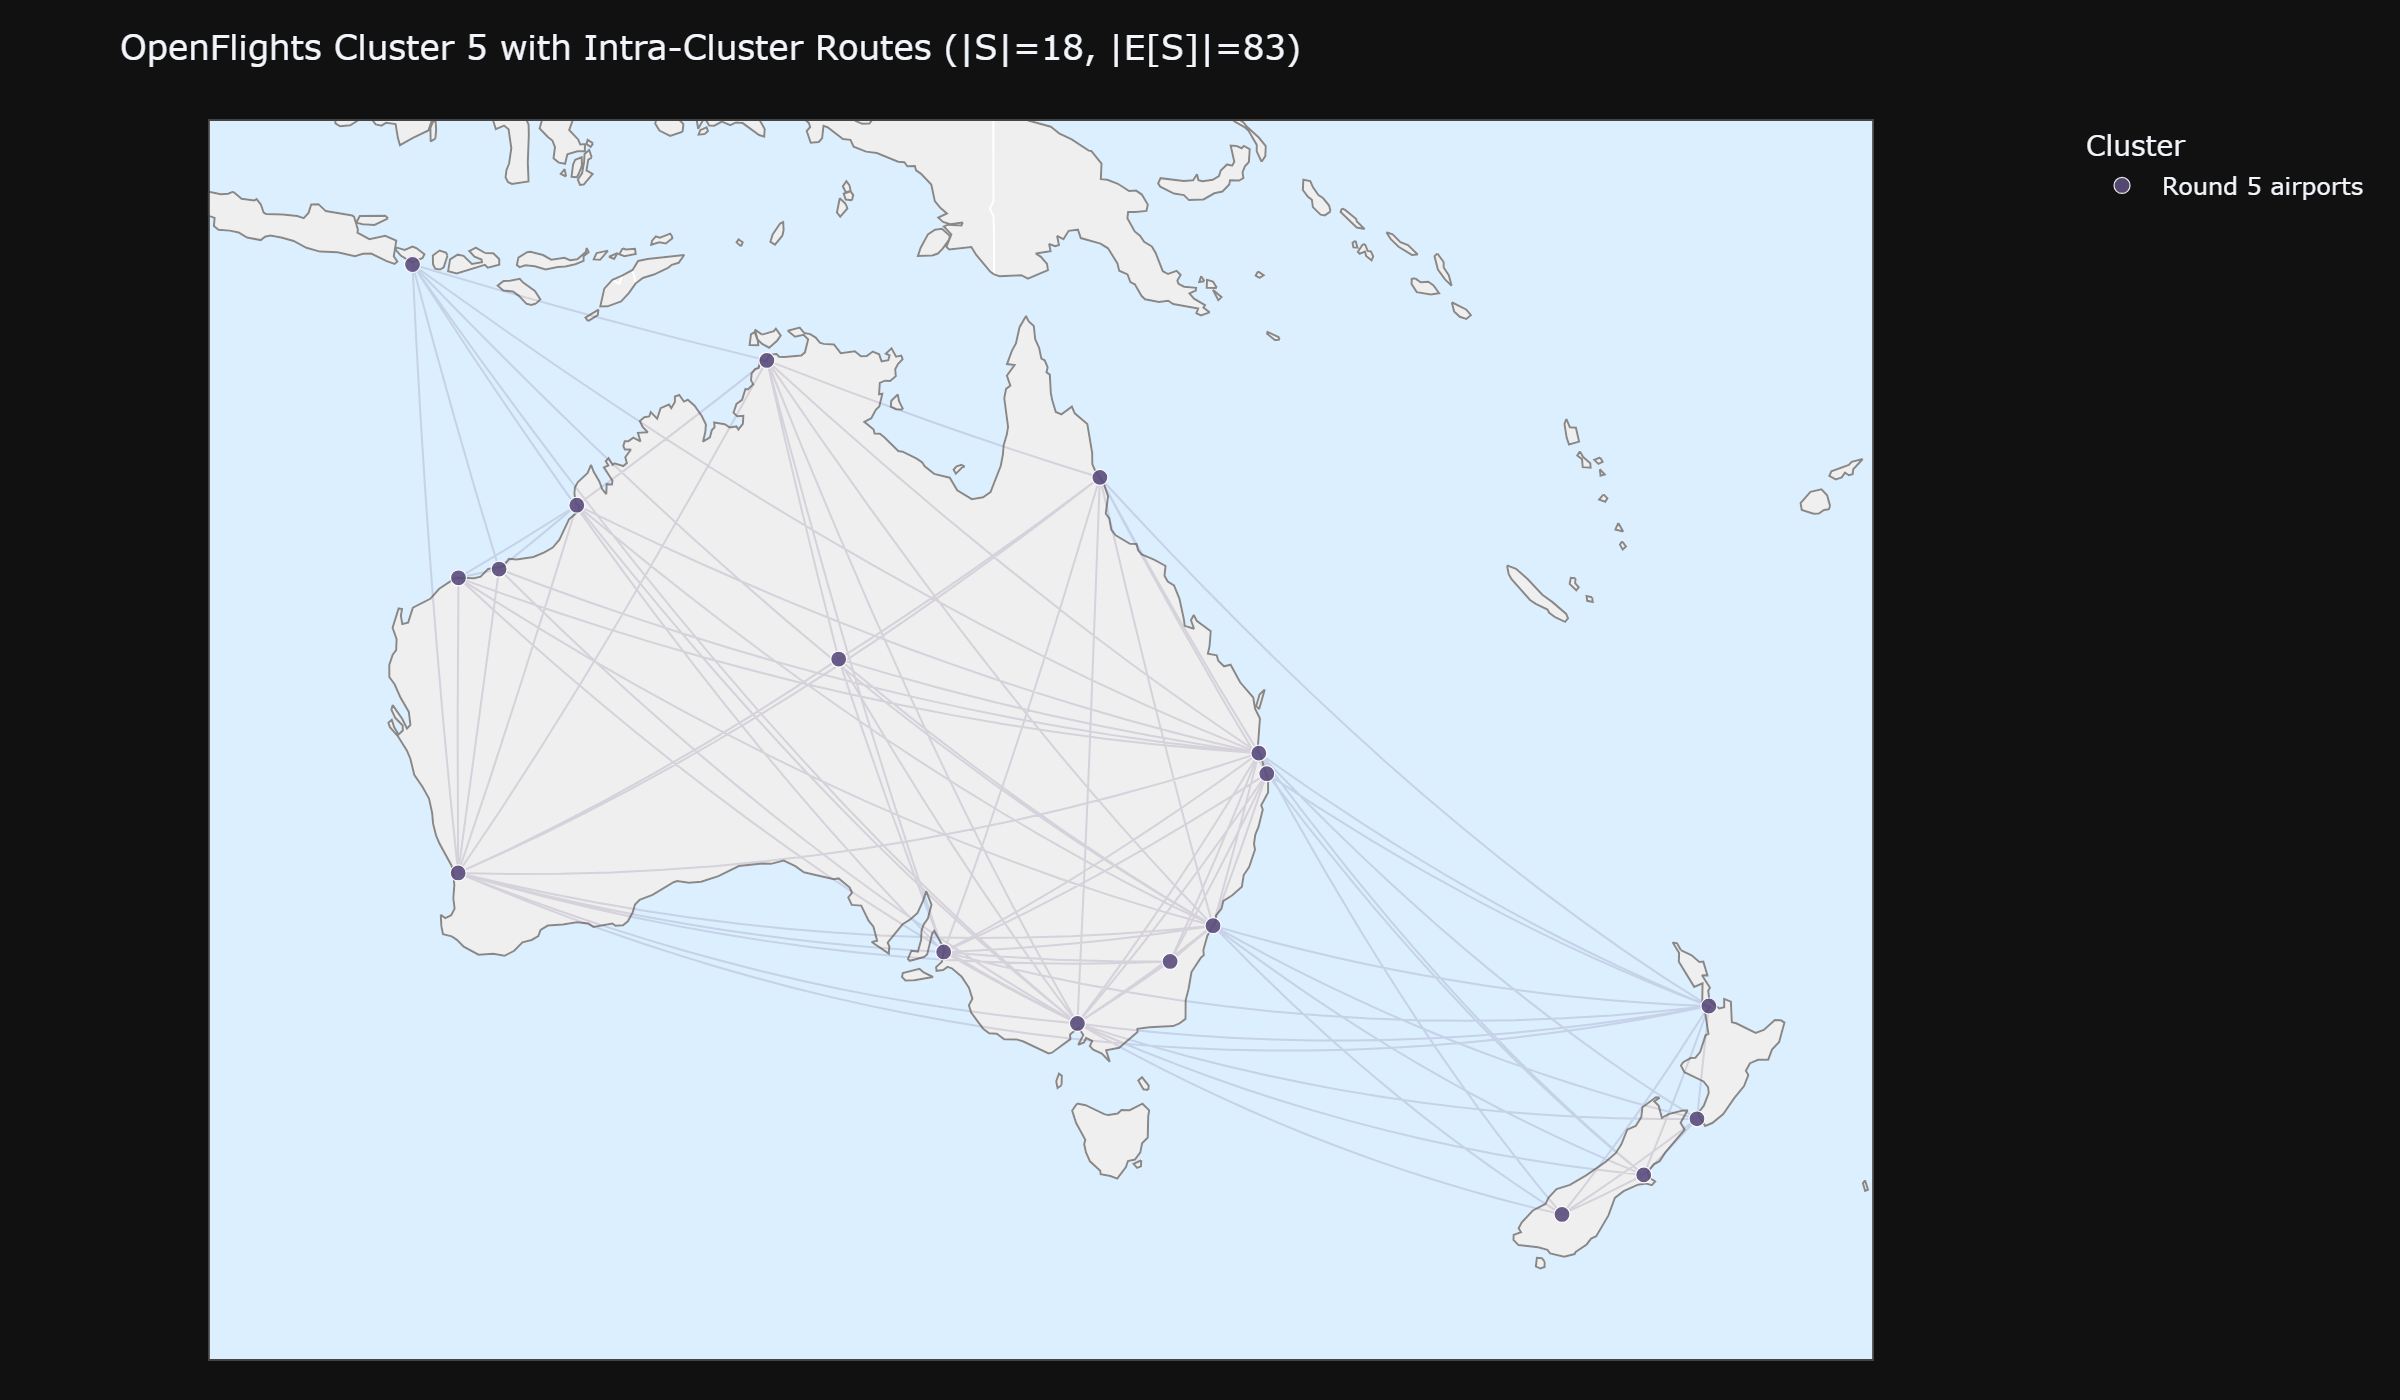

Saved cluster map to generated\openflights_cluster_5.png


In [46]:
# AI-assisted visualization code.
# It creates one overview map for all clusters and one route map for each cluster.

import csv
from IPython.display import Markdown, display
import os
import plotly.graph_objects as go

with open('data/openflights/nodes.csv', newline='', encoding='utf-8') as f:
    reader = csv.reader(f)
    next(reader)
    openflights_nodes = {
        int(row[0]): {
            'name': row[2],
            'city': row[3],
            'country': row[4],
            'lat': float(row[7]),
            'lon': float(row[8]),
        }
        for row in reader
    }

openflights_edges = set()
with open('data/openflights_edges_cleaned.csv', newline='', encoding='utf-8') as f:
    for row in csv.reader(f):
        u = int(row[0])
        v = int(row[1])
        if u == v:
            continue
        openflights_edges.add((u, v) if u < v else (v, u))

cluster_colors = ['#d1495b', '#edae49', '#66a182', '#2e86ab', '#5c4d7d']

def airport_hover_text(round_idx, node):
    return f"Round {round_idx}<br>{node['name']} ({node['city']}, {node['country']})"

def cluster_nodes(vertex_set):
    node_ids = sorted(vertex_set)
    return node_ids, [openflights_nodes[node_id] for node_id in node_ids]

def cluster_edge_coordinates(vertex_set):
    vertex_set = set(vertex_set)
    lon = []
    lat = []
    edge_count = 0
    for u, v in openflights_edges:
        if u in vertex_set and v in vertex_set:
            lon.extend([openflights_nodes[u]['lon'], openflights_nodes[v]['lon'], None])
            lat.extend([openflights_nodes[u]['lat'], openflights_nodes[v]['lat'], None])
            edge_count += 1
    return lon, lat, edge_count

def padded_range(values, lower_bound, upper_bound):
    minimum = min(values)
    maximum = max(values)
    span = maximum - minimum
    if span > 300:
        return None
    padding = max(5, span * 0.15)
    return [max(lower_bound, minimum - padding), min(upper_bound, maximum + padding)]

def apply_geo_style(fig, title, lon_range=None, lat_range=None):
    geo_options = dict(
        projection_type='natural earth',
        showland=True,
        landcolor='#efefef',
        showcountries=True,
        countrycolor='#ffffff',
        showocean=True,
        oceancolor='#dcefff',
        showcoastlines=True,
        coastlinecolor='#888888',
    )
    if lon_range is not None:
        geo_options['lonaxis'] = dict(range=lon_range)
    if lat_range is not None:
        geo_options['lataxis'] = dict(range=lat_range)
    fig.update_geos(**geo_options)
    fig.update_layout(
        title=title,
        legend_title_text='Cluster',
        width=1200,
        height=700,
        margin=dict(l=20, r=20, t=60, b=20),
    )

os.makedirs('generated', exist_ok=True)

overview_fig = go.Figure()
for result, color in zip(openflights_disjoint_subgraphs, cluster_colors):
    _, nodes = cluster_nodes(result['vertex_set'])
    overview_fig.add_trace(go.Scattergeo(
        lon=[node['lon'] for node in nodes],
        lat=[node['lat'] for node in nodes],
        text=[airport_hover_text(result['round'], node) for node in nodes],
        mode='markers',
        marker=dict(size=7, color=color, opacity=0.85, line=dict(width=0.5, color='white')),
        name=f"Round {result['round']} (|S|={result['num_vertices']})",
        hovertemplate="%{text}<extra></extra>",
    ))

apply_geo_style(overview_fig, 'OpenFlights Dense Subgraphs on a World Map')
overview_fig.show()
overview_path = os.path.join('generated', 'openflights_clusters_world_map.png')
overview_fig.write_image(overview_path, width=1200, height=700, scale=2)
print(f"Saved overview map to {overview_path}")

for result, color in zip(openflights_disjoint_subgraphs, cluster_colors):
    node_ids, nodes = cluster_nodes(result['vertex_set'])
    edge_lon, edge_lat, edge_count = cluster_edge_coordinates(node_ids)

    cluster_fig = go.Figure()
    cluster_fig.add_trace(go.Scattergeo(
        lon=edge_lon,
        lat=edge_lat,
        mode='lines',
        line=dict(width=1, color=color),
        opacity=0.18,
        hoverinfo='skip',
        showlegend=False,
    ))
    cluster_fig.add_trace(go.Scattergeo(
        lon=[node['lon'] for node in nodes],
        lat=[node['lat'] for node in nodes],
        text=[airport_hover_text(result['round'], node) for node in nodes],
        mode='markers',
        marker=dict(size=8, color=color, opacity=0.9, line=dict(width=0.6, color='white')),
        name=f"Round {result['round']} airports",
        hovertemplate="%{text}<extra></extra>",
    ))

    lon_range = padded_range([node['lon'] for node in nodes], -180, 180)
    lat_range = padded_range([node['lat'] for node in nodes], -90, 90)
    apply_geo_style(
        cluster_fig,
        f"OpenFlights Cluster {result['round']} with Intra-Cluster Routes (|S|={result['num_vertices']}, |E[S]|={edge_count})",
        lon_range,
        lat_range,
    )
    cluster_fig.show()

    cluster_path = os.path.join('generated', f"openflights_cluster_{result['round']}.png")
    cluster_fig.write_image(cluster_path, width=1200, height=700, scale=2)
    print(f"Saved cluster map to {cluster_path}")


### Experiments for the Facebook Dataset

In [47]:
import csv

facebook_disjoint_subgraphs = runDisjointSubgraphExtraction('data/musae_facebook_edges_cleaned.csv')

for result in facebook_disjoint_subgraphs:
    print(f"Round {result['round']}:")
    print(f"|S| = {result['num_vertices']}, density = {result['score']}\n")

with open('data/facebook_large/musae_facebook_target.csv', newline='', encoding='utf-8') as f:
    facebook_page_names = {
        int(row['id']): row['page_name']
        for row in csv.DictReader(f)
    }

facebook_densest_page_names = sorted(
    facebook_page_names[node_id]
    for node_id in facebook_disjoint_subgraphs[0]['vertex_set']
)

#for result in facebook_disjoint_subgraphs:
#    print(f"\n\nRound {result['round']}:")
#    print(sorted(facebook_page_names[node_id] for node_id in result['vertex_set']))

print("\n".join(facebook_densest_page_names))

Finished reading graph with 22470 nodes and 170823 edges.
Finished reading graph with 22091 nodes and 144246 edges.
Finished reading graph with 21994 nodes and 138591 edges.
Finished reading graph with 21232 nodes and 109432 edges.
Finished reading graph with 21168 nodes and 107522 edges.
Round 1:
|S| = 324, density = 35.0

Round 2:
|S| = 89, density = 25.359550561797754

Round 3:
|S| = 662, density = 20.358006042296072

Round 4:
|S| = 55, density = 17.345454545454544

Round 5:
|S| = 311, density = 15.434083601286174



['1-2 SBCT, 7th Infantry Division',
 '101st Airborne Division (Air Assault)',
 '101st Airborne Division Sustainment Brigade "Lifeliners"',
 '101st CAB, Wings of Destiny',
 '160th Signal Brigade',
 '16th Combat Aviation Brigade',
 '173rd Airborne Brigade',
 '1st Armored Brigade Combat Team, 3rd Infantry Division',
 '1st Armored Division',
 '1st Battalion, 506th Infantry Regiment "Red Currahee"',
 '1st Brigade Combat Team "Bastogne"',
 '1st Brigade Combat Team, 82nd Airborne Division',
 '1st Cavalry Division',
 '1st Combat Aviation Brigade, 1st Infantry Division',
 '1st Infantry Division',
 '1st Stryker Brigade Combat Team, 4th Infantry Division',
 '21st Theater Sustainment Command',
 '24: Legacy',
 '29th Infantry Division',
 '2nd Armored Brigade Combat Team, 1st Cavalry Division',
 '2nd Brigade Combat Team "STRIKE"',
 '2nd Brigade Combat Team, 3rd Infantry Division',
 '2nd Brigade Combat Team, 82nd Airborne Division',
 '2nd Infantry Brigade Combat Team, 4th Infantry Division',
 '2nd Str

## Experiments for Optimal Quasi Clique

Now re-run the experiments from above with the new objective function and compare the results to the previous outputs.

### Experiments for the OpenFlights Dataset

In [48]:
openflights_tsourakakis_subgraphs = runDisjointSubgraphExtraction('data/openflights_edges_cleaned.csv', objective='tsourakakis')

for result in openflights_tsourakakis_subgraphs:
    density = objectiveValue(result['num_edges'], result['num_vertices'], objective='density')
    clique_likeness = objectiveValue(result['num_edges'], result['num_vertices'], objective='clique_likeness')
    print(f"Round {result['round']}: |S| = {result['num_vertices']}, density = {density:.4f}, clique-likeness = {clique_likeness:.4f}")

comparison_rows = [
    '| Round | Density: \\|S\\| | density | clique-like | \\| | Tsourakakis: \\|S\\| | density | clique-like |',
    '|---:|---:|---:|---:|---:|---:|---:|---:|'
]

for i in range(5):
    density_result = openflights_disjoint_subgraphs[i]
    density_density = objectiveValue(density_result['num_edges'], density_result['num_vertices'], objective='density')
    density_clique = objectiveValue(density_result['num_edges'], density_result['num_vertices'], objective='clique_likeness')

    tsourakakis_result = openflights_tsourakakis_subgraphs[i]
    tsourakakis_density = objectiveValue(tsourakakis_result['num_edges'], tsourakakis_result['num_vertices'], objective='density')
    tsourakakis_clique = objectiveValue(tsourakakis_result['num_edges'], tsourakakis_result['num_vertices'], objective='clique_likeness')
    comparison_rows.append(
        f"| {i + 1} | {density_result['num_vertices']} | {density_density:.4f} | {density_clique:.4f} | \\| | {tsourakakis_result['num_vertices']} | {tsourakakis_density:.4f} | {tsourakakis_clique:.4f} |"
    )

display(Markdown('\n'.join(comparison_rows)))


Finished reading graph with 3214 nodes and 18858 edges.
Finished reading graph with 2989 nodes and 11956 edges.
Finished reading graph with 2755 nodes and 8812 edges.
Finished reading graph with 2617 nodes and 6492 edges.
Finished reading graph with 2515 nodes and 5647 edges.
Round 1: |S| = 93, density = 24.2688, clique-likeness = 0.5276
Round 2: |S| = 45, density = 18.1333, clique-likeness = 0.8242
Round 3: |S| = 55, density = 16.9273, clique-likeness = 0.6269
Round 4: |S| = 29, density = 8.5517, clique-likeness = 0.6108
Round 5: |S| = 22, density = 5.7727, clique-likeness = 0.5498


| Round | Density: \|S\| | density | clique-like | \| | Tsourakakis: \|S\| | density | clique-like |
|---:|---:|---:|---:|---:|---:|---:|---:|
| 1 | 180 | 25.3778 | 0.2836 | \| | 93 | 24.2688 | 0.5276 |
| 2 | 53 | 14.7547 | 0.5675 | \| | 45 | 18.1333 | 0.8242 |
| 3 | 29 | 7.4828 | 0.5345 | \| | 55 | 16.9273 | 0.6269 |
| 4 | 57 | 5.3860 | 0.1924 | \| | 29 | 8.5517 | 0.6108 |
| 5 | 18 | 4.6111 | 0.5425 | \| | 22 | 5.7727 | 0.5498 |

### AI-Assisted OpenFlights Visualization for the Tsourakakis Objective

The following cell uses the same map style as above and visualizes the five OpenFlights clusters found with the Tsourakakis objective.

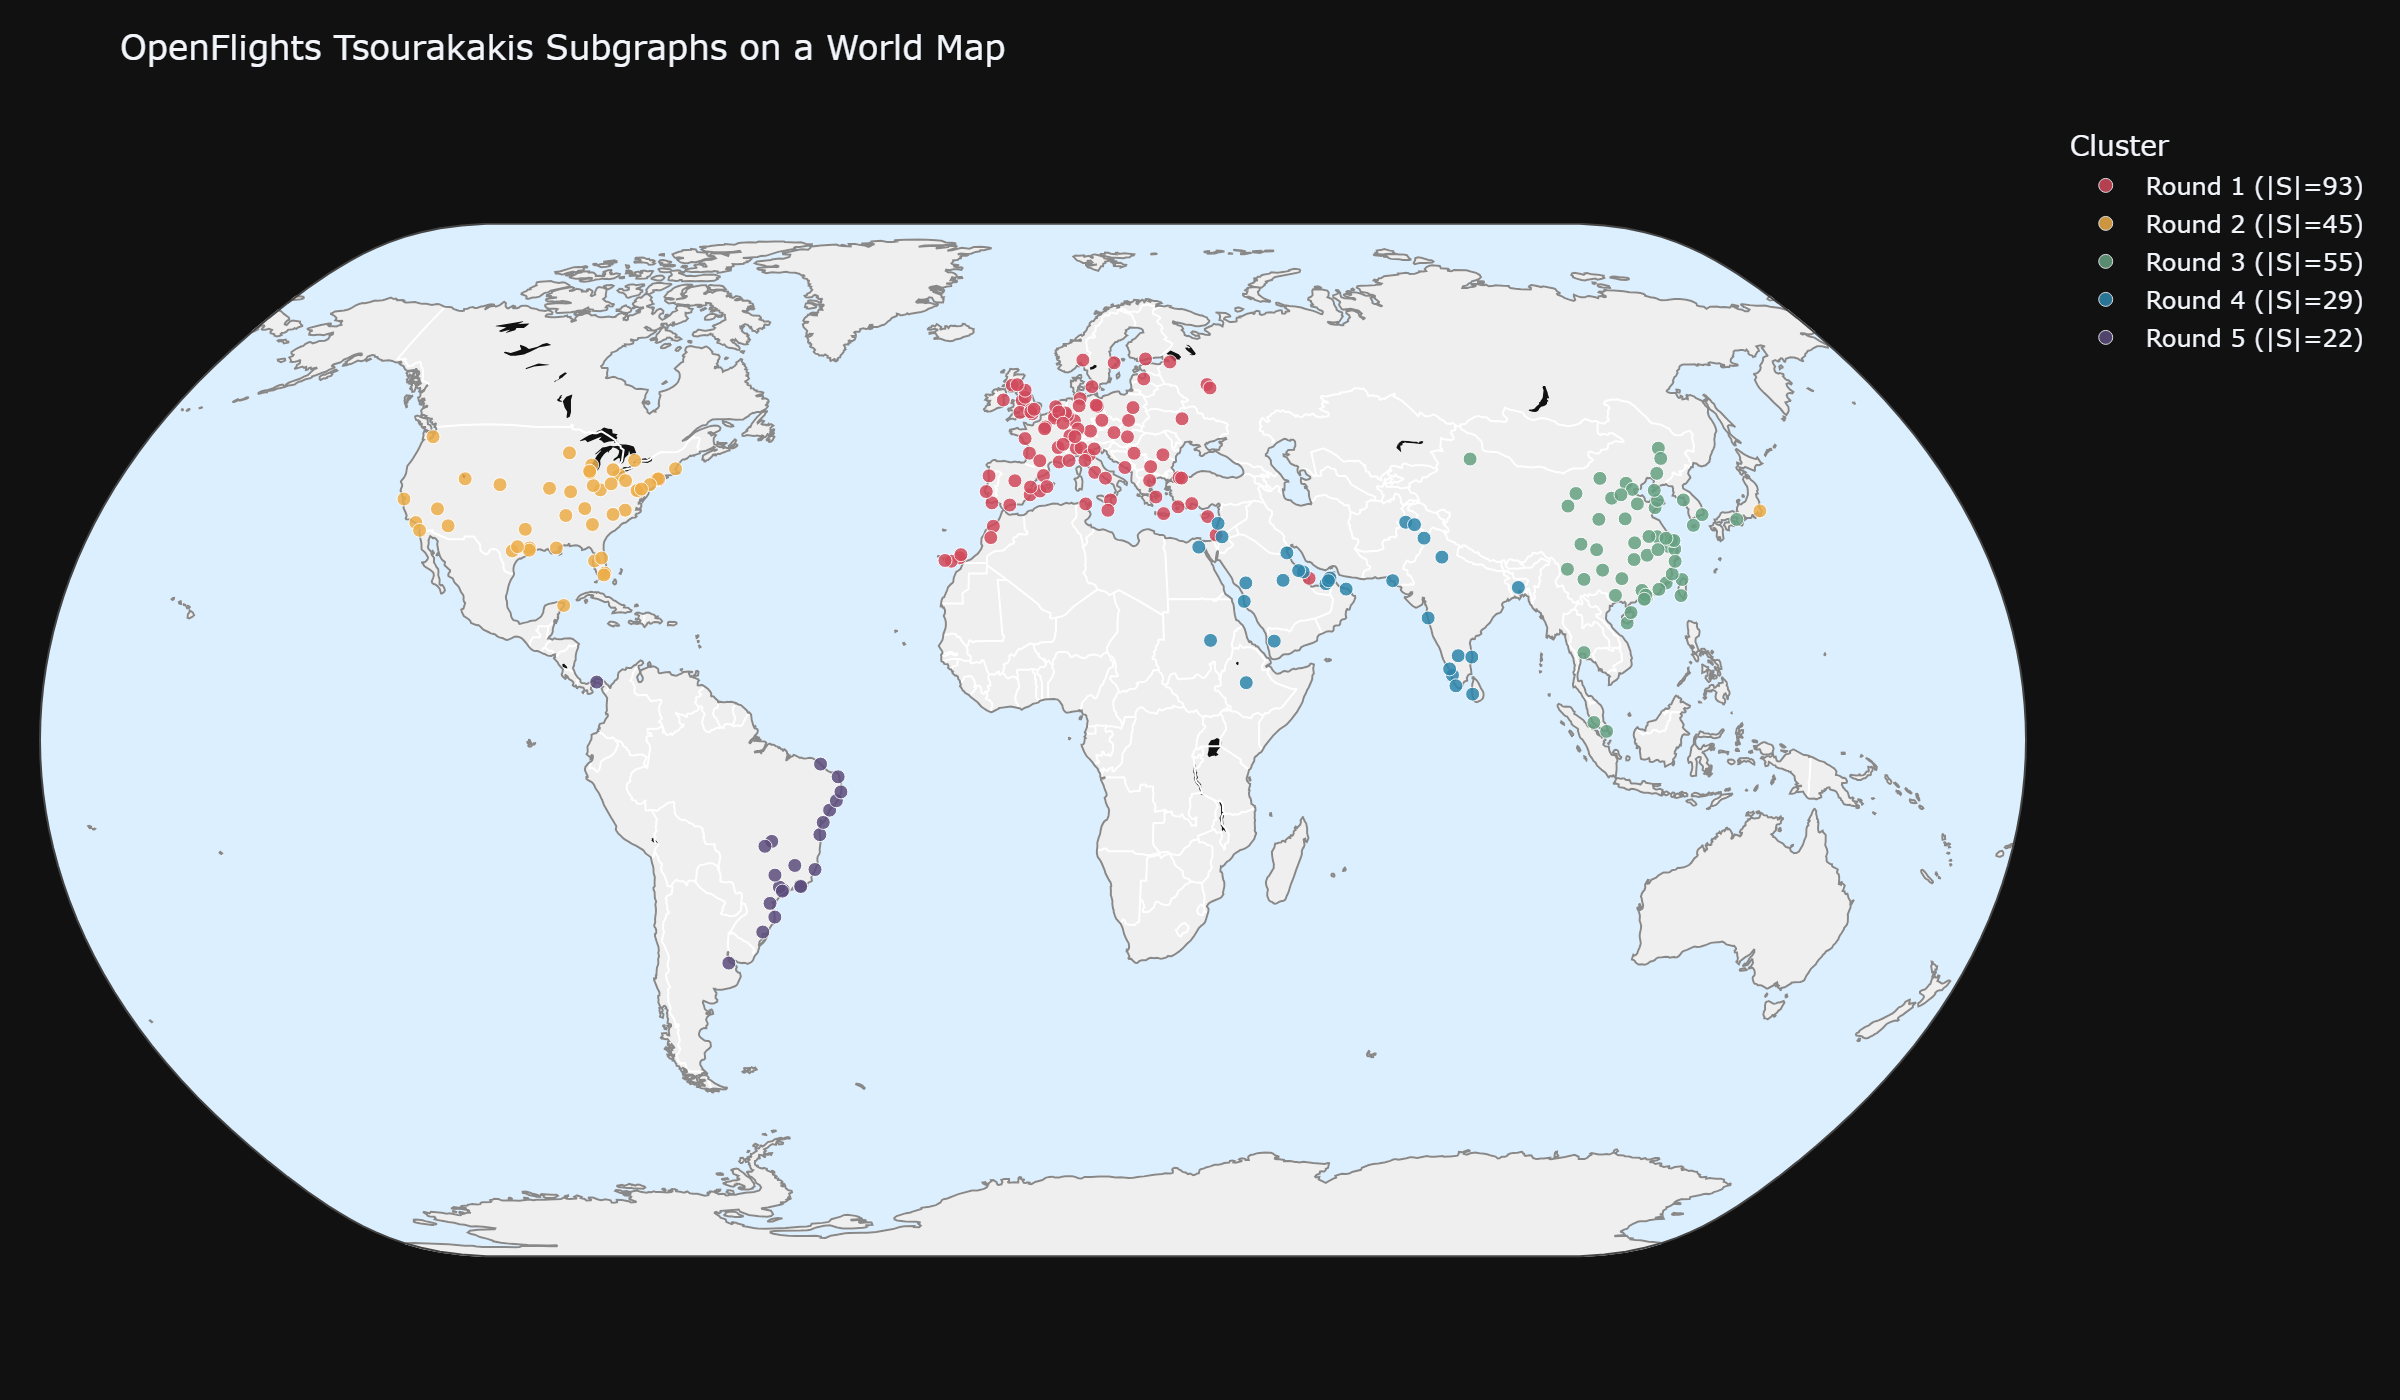

Saved Tsourakakis overview map to generated\openflights_tsourakakis_world_map.png


In [49]:
tsourakakis_overview_fig = go.Figure()
for result, color in zip(openflights_tsourakakis_subgraphs, cluster_colors):
    _, nodes = cluster_nodes(result['vertex_set'])
    tsourakakis_overview_fig.add_trace(go.Scattergeo(
        lon=[node['lon'] for node in nodes],
        lat=[node['lat'] for node in nodes],
        text=[airport_hover_text(result['round'], node) for node in nodes],
        mode='markers',
        marker=dict(size=7, color=color, opacity=0.85, line=dict(width=0.5, color='white')),
        name=f"Round {result['round']} (|S|={result['num_vertices']})",
        hovertemplate="%{text}<extra></extra>",
    ))

apply_geo_style(tsourakakis_overview_fig, 'OpenFlights Tsourakakis Subgraphs on a World Map')
tsourakakis_overview_fig.show()
tsourakakis_overview_path = os.path.join('generated', 'openflights_tsourakakis_world_map.png')
tsourakakis_overview_fig.write_image(tsourakakis_overview_path, width=1200, height=700, scale=2)
print(f"Saved Tsourakakis overview map to {tsourakakis_overview_path}")


### Experiments for the Facebook Dataset

In [50]:
facebook_tsourakakis_subgraphs = runDisjointSubgraphExtraction('data/musae_facebook_edges_cleaned.csv', objective='tsourakakis')

for result in facebook_tsourakakis_subgraphs:
    density = objectiveValue(result['num_edges'], result['num_vertices'], objective='density')
    clique_likeness = objectiveValue(result['num_edges'], result['num_vertices'], objective='clique_likeness')
    print(f"Round {result['round']}: |S| = {result['num_vertices']}, density = {density:.4f}, clique-likeness = {clique_likeness:.4f}")

comparison_rows = [
    '| Round | Density: \\|S\\| | density | clique-like | \\| | Tsourakakis: \\|S\\| | density | clique-like |',
    '|---:|---:|---:|---:|---:|---:|---:|---:|'
]

for i in range(5):
    density_result = facebook_disjoint_subgraphs[i]
    density_density = objectiveValue(density_result['num_edges'], density_result['num_vertices'], objective='density')
    density_clique = objectiveValue(density_result['num_edges'], density_result['num_vertices'], objective='clique_likeness')

    tsourakakis_result = facebook_tsourakakis_subgraphs[i]
    tsourakakis_density = objectiveValue(tsourakakis_result['num_edges'], tsourakakis_result['num_vertices'], objective='density')
    tsourakakis_clique = objectiveValue(tsourakakis_result['num_edges'], tsourakakis_result['num_vertices'], objective='clique_likeness')
    comparison_rows.append(
        f"| {i + 1} | {density_result['num_vertices']} | {density_density:.4f} | {density_clique:.4f} | \\| | {tsourakakis_result['num_vertices']} | {tsourakakis_density:.4f} | {tsourakakis_clique:.4f} |"
    )

display(Markdown('\n'.join(comparison_rows)))


#for result in facebook_tsourakakis_subgraphs:
#    print(f"\n\nRound {result['round']}:")
#    print(sorted(facebook_page_names[node_id] for node_id in result['vertex_set']))

Finished reading graph with 22470 nodes and 170823 edges.
Finished reading graph with 22408 nodes and 168565 edges.
Finished reading graph with 22251 nodes and 150089 edges.
Finished reading graph with 22154 nodes and 144415 edges.
Finished reading graph with 22111 nodes and 143463 edges.
Round 1: |S| = 60, density = 29.3167, clique-likeness = 0.9938
Round 2: |S| = 129, density = 33.3566, clique-likeness = 0.5212
Round 3: |S| = 89, density = 25.3596, clique-likeness = 0.5764
Round 4: |S| = 38, density = 17.6579, clique-likeness = 0.9545
Round 5: |S| = 41, density = 17.7073, clique-likeness = 0.8854


| Round | Density: \|S\| | density | clique-like | \| | Tsourakakis: \|S\| | density | clique-like |
|---:|---:|---:|---:|---:|---:|---:|---:|
| 1 | 324 | 35.0000 | 0.2167 | \| | 60 | 29.3167 | 0.9938 |
| 2 | 89 | 25.3596 | 0.5764 | \| | 129 | 33.3566 | 0.5212 |
| 3 | 662 | 20.3580 | 0.0616 | \| | 89 | 25.3596 | 0.5764 |
| 4 | 55 | 17.3455 | 0.6424 | \| | 38 | 17.6579 | 0.9545 |
| 5 | 311 | 15.4341 | 0.0996 | \| | 41 | 17.7073 | 0.8854 |



Round 1:
['24: Legacy', 'APB FOX', 'American Grit', 'BOOM', 'Beat Shazam', "Bob's Burgers", 'Bones', 'Bordertown', 'Brooklyn Nine-Nine', "Cooper Barrett's Guide to Surviving Life", 'Coupled', 'Empire', 'FOX Teen Choice Awards', 'Family Guy', 'Famous', 'Ghosted', 'Glee', 'Gotham', 'Grandfathered', "Hell's Kitchen", 'Home Free FOX', 'Hotel Hell', 'Houdini & Doyle', 'Kicking & Screaming', 'LA to Vegas', 'Lethal Weapon FOX', 'Love Connection FOX', 'Lucifer', 'Making History', 'MasterChef', 'MasterChef Junior', 'My Kitchen Rules', 'New Girl', "New Year's Eve on FOX", 'Party Over Here', 'Pitch', 'Prison Break', 'Rosewood', 'STAR', 'Scream Queens', 'Second Chance', 'Shots Fired', 'Showtime At The Apollo', 'Sleepy Hollow', 'So You Think You Can Dance', 'Son of Zorn', 'Superhuman', 'The Exorcist FOX', 'The F Word', 'The Gifted', 'The Grinder', 'The Last Man on Earth', 'The Mick', 'The Orville', 'The Resident', 'The Simpsons', 'The X-Files', 'Wayward Pines', 'World’s Funniest', 'You The Jury']

**How do the results differ?**
The Tsourakakis objective generally returns smaller but more clique-like subgraphs than the density objective.
The effect is visible on OpenFlights and much stronger on Facebook, where the density objective often keeps larger but looser groups, while the Tsourakakis objective favors tighter communities.